# BranchHit@10 Plot (Simple)

CSV를 읽어 pyplot으로 라인 차트만 그립니다.


Using: ../results/analysis/branch_hit10_by_iter_compare_subset_macro.csv


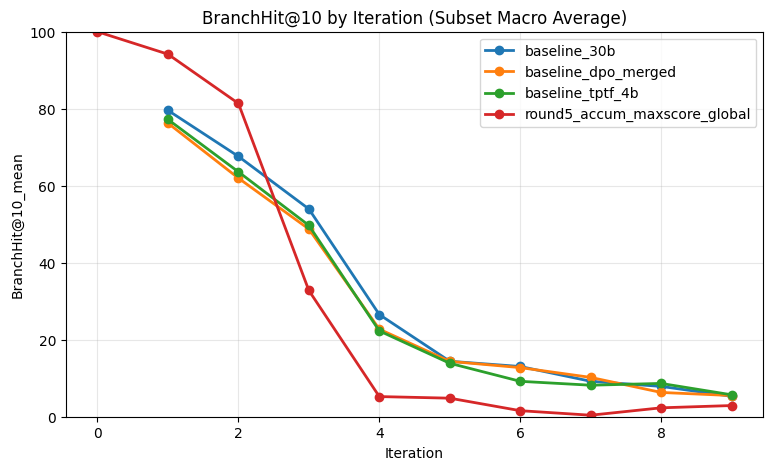

In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def pick_existing_path(filename: str) -> Path:
    candidates = [
        Path("results/analysis") / filename,
        Path("../results/analysis") / filename,
        Path("../../results/analysis") / filename,
        Path("/data4/jongho/lattice/results/analysis") / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError("Missing file. checked=" + ", ".join(str(x) for x in candidates))


iter_csv = pick_existing_path("branch_hit10_by_iter_compare_subset_macro.csv")
print("Using:", iter_csv)
iter_df = pd.read_csv(iter_csv)

plt.figure(figsize=(9, 5))
for run_name, group in iter_df.groupby("run"):
    group = group.sort_values("iter")
    plt.plot(group["iter"], group["BranchHit@10_mean"], marker="o", linewidth=2, label=run_name)

plt.title("BranchHit@10 by Iteration (Subset Macro Average)")
plt.xlabel("Iteration")
plt.ylabel("BranchHit@10_mean")
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()
plt.show()


Using: ../results/analysis/branch_hit10_by_depth_iter_compare.csv


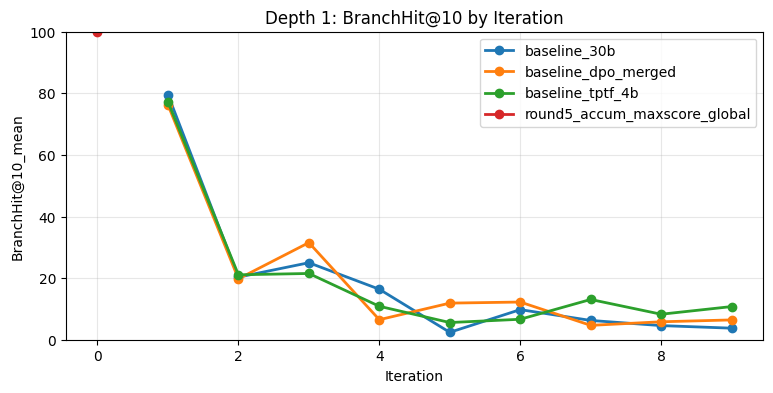

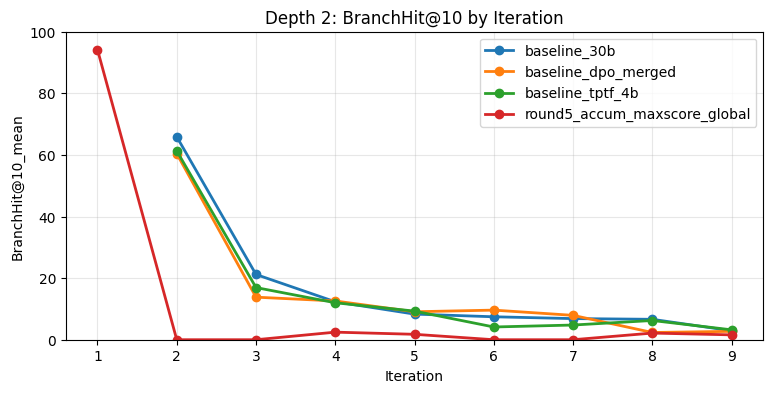

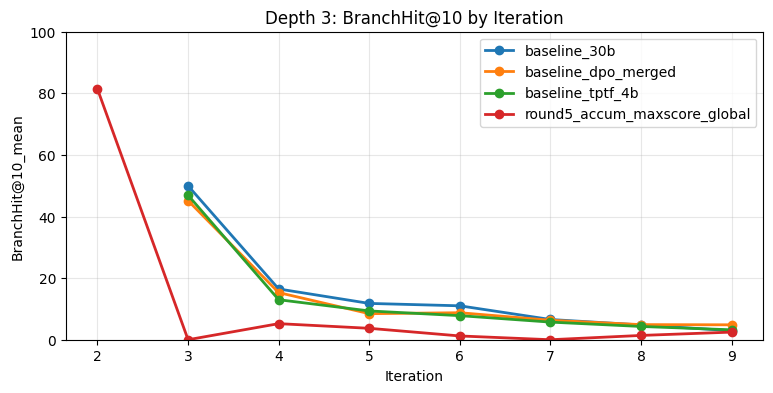

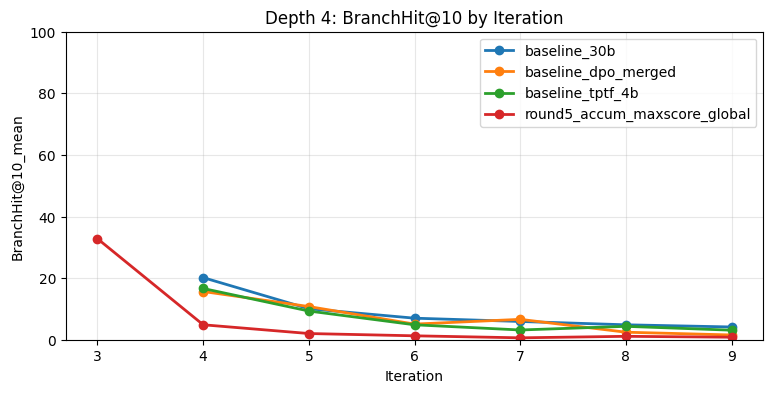

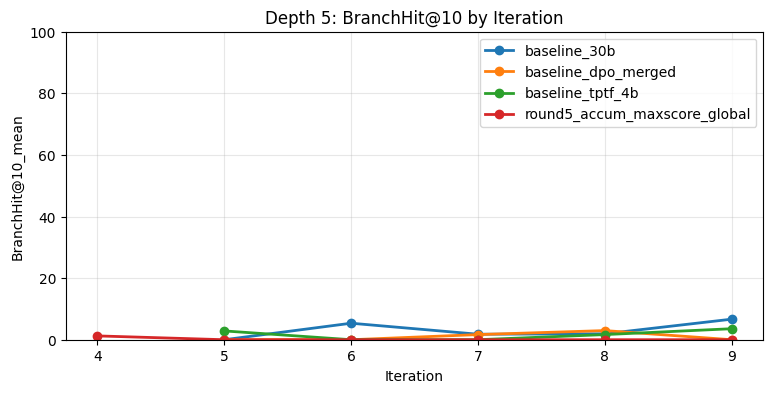

In [21]:
depth_csv = pick_existing_path("branch_hit10_by_depth_iter_compare.csv")
print("Using:", depth_csv)
depth_df = pd.read_csv(depth_csv)

for depth in [1, 2, 3, 4, 5]:
    sub = depth_df[depth_df["depth"] == depth]
    plt.figure(figsize=(9, 4))
    for run_name, group in sub.groupby("run"):
        group = group.sort_values("iter")
        plt.plot(group["iter"], group["BranchHit@10_mean"], marker="o", linewidth=2, label=run_name)
    plt.title(f"Depth {depth}: BranchHit@10 by Iteration")
    plt.xlabel("Iteration")
    plt.ylabel("BranchHit@10_mean")
    plt.ylim(0, 100)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


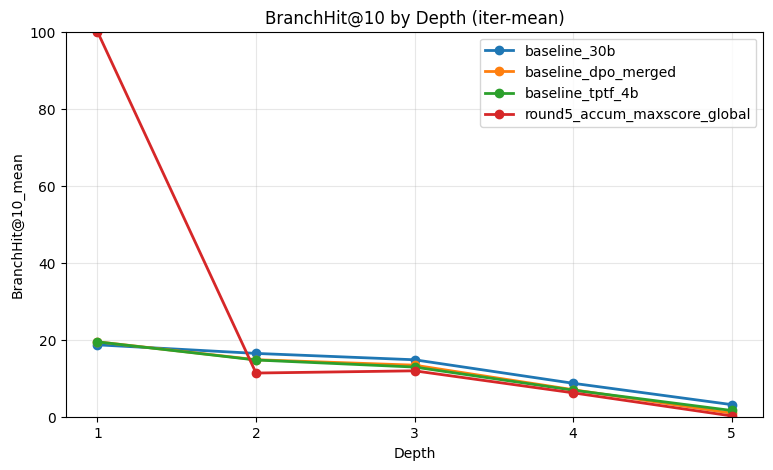

In [22]:
# x축=depth 라인 플롯
# TARGET_ITER를 정수로 설정하면 해당 iteration만, None이면 iteration 평균으로 그림.
TARGET_ITER = None

plot_df = depth_df.copy()
if TARGET_ITER is not None:
    plot_df = plot_df[plot_df["iter"] == int(TARGET_ITER)]
else:
    plot_df = (
        plot_df
        .groupby(["run", "depth"], as_index=False)["BranchHit@10_mean"]
        .mean()
    )

plt.figure(figsize=(9, 5))
for run_name, group in plot_df.groupby("run"):
    group = group.sort_values("depth")
    plt.plot(group["depth"], group["BranchHit@10_mean"], marker="o", linewidth=2, label=run_name)

title_suffix = f"iter={TARGET_ITER}" if TARGET_ITER is not None else "iter-mean"
plt.title(f"BranchHit@10 by Depth ({title_suffix})")
plt.xlabel("Depth")
plt.ylabel("BranchHit@10_mean")
plt.xticks([1, 2, 3, 4, 5])
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()
plt.show()
